# Cosine Similarity — Anomaly Detection Baseline

Two-phase analysis on Impressionism embeddings (ResNet-50, 2048-dim):

- **Phase 1** — Global centroid baseline: one Impressionism centroid, score every painting against it
- **Phase 2** — Per-artist centroids: filter to artists with ≥20 images, score each painting against its own artist's centroid

Scores are saved to `results/` for later comparison with Isolation Forest, Wasserstein, and KS test.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

BASE_DIR = Path('..')
EMBEDDINGS_DIR = BASE_DIR / 'embeddings'
RESULTS_DIR = BASE_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

# Load Data
embeddings_raw = np.load(EMBEDDINGS_DIR / 'image_embeddings.npy')
metadata = pd.read_csv(EMBEDDINGS_DIR / 'embedding_metadata.csv').reset_index(drop=True)

# L2-normalise => cosine similarity = dot product
embeddings = normalize(embeddings_raw, norm='l2')

print('Embeddings shape:', embeddings.shape)
print('Metadata shape:  ', metadata.shape)
print('Artists total:   ', metadata['artist'].nunique())

Embeddings shape: (1500, 2048)
Metadata shape:   (1500, 11)
Artists total:    175


---
## Phase 1 — Global Impressionism Centroid (Baseline)

Compute a single centroid for all 1,500 Impressionism paintings and measure how far each painting drifts from it.
Low similarity → the painting is atypical of the genre as a whole.

In [ ]:
# Global centroid 
global_centroid = embeddings.mean(axis=0, keepdims=True)
global_centroid = normalize(global_centroid, norm='l2')

# Cosine similarity of every painting to the centroid
global_scores = cosine_similarity(embeddings, global_centroid).flatten()
metadata['global_cosine_sim'] = global_scores
metadata['global_anomaly_score'] = 1 - global_scores  # higher = more anomalous

print(f'Mean similarity : {global_scores.mean():.4f}')
print(f'Std             : {global_scores.std():.4f}')
print(f'Min             : {global_scores.min():.4f}')
print(f'Max             : {global_scores.max():.4f}')

Mean similarity : 0.5650
Std             : 0.0880
Min             : 0.2071
Max             : 0.7776


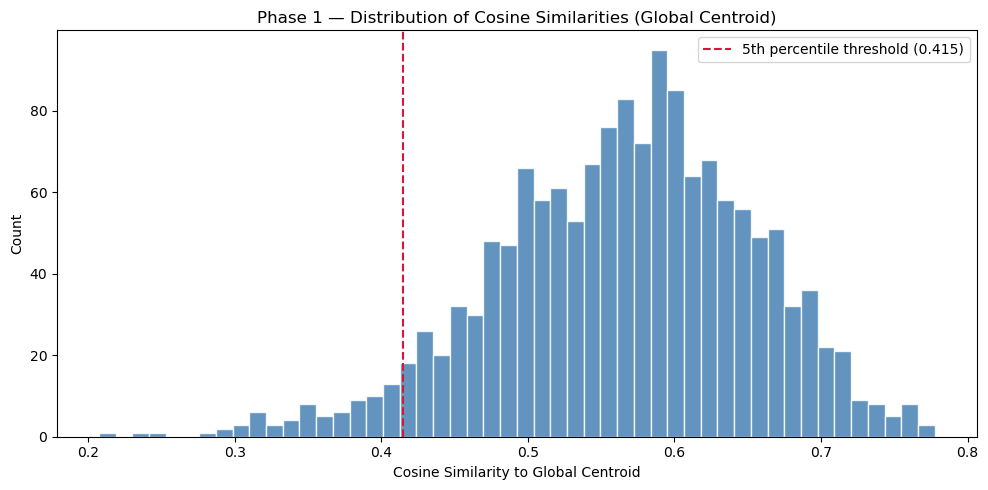

Flagged as anomalies (bottom 5%): 75 paintings


In [ ]:
# Histogram of global similarity scores
threshold_global = np.percentile(global_scores, 5)  # bottom 5% = flagged

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(global_scores, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(threshold_global, color='crimson', linestyle='--', linewidth=1.5,
           label=f'5th percentile threshold ({threshold_global:.3f})')
ax.set_xlabel('Cosine Similarity to Global Centroid')
ax.set_ylabel('Count')
ax.set_title('Phase 1 — Distribution of Cosine Similarities (Global Centroid)')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase1_global_similarity_histogram.png', dpi=150)
plt.show()
print(f'Flagged as anomalies (bottom 5%): {(global_scores <= threshold_global).sum()} paintings')

c:\Users\Yeva\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


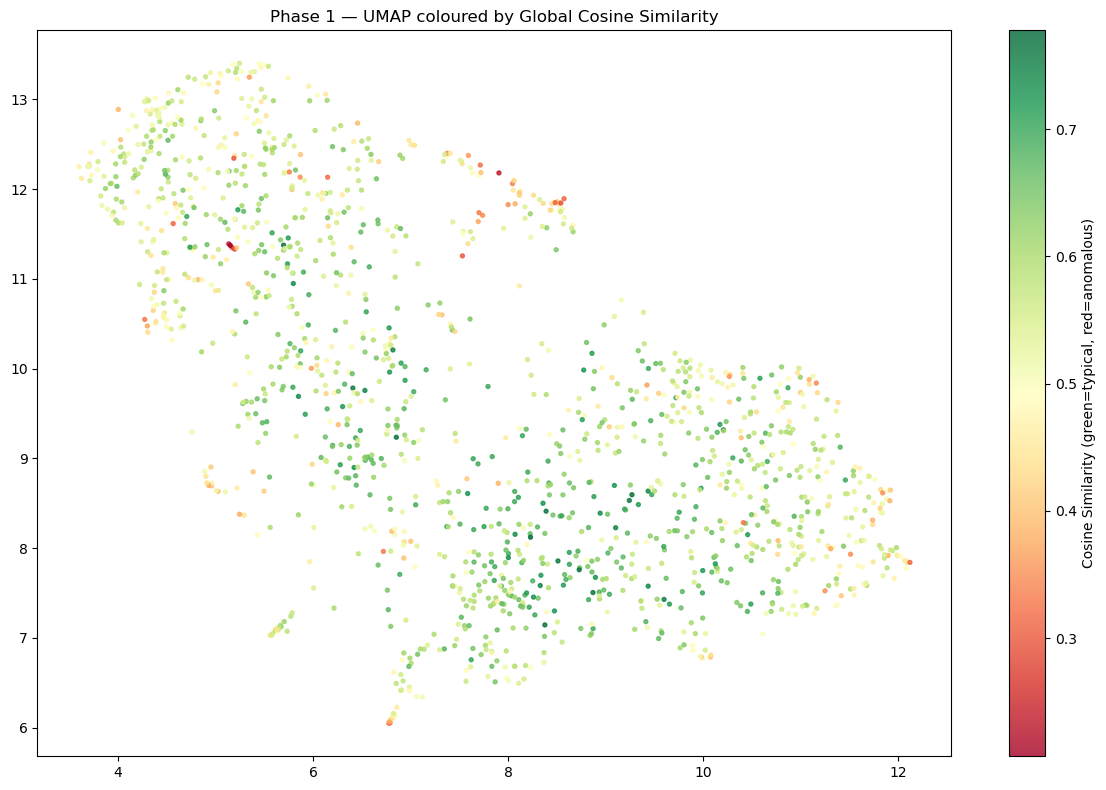

In [ ]:
# UMAP coloured by global anomaly score 
try:
    import umap
except ImportError:
    raise ImportError('Install umap-learn: pip install umap-learn')

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
coords = reducer.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(coords[:, 0], coords[:, 1],
                c=global_scores, cmap='RdYlGn',
                s=8, alpha=0.8, vmin=global_scores.min(), vmax=global_scores.max())
plt.colorbar(sc, ax=ax, label='Cosine Similarity (green=typical, red=anomalous)')
ax.set_title('Phase 1 — UMAP coloured by Global Cosine Similarity')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase1_umap_global_similarity.png', dpi=150)
plt.show()

In [ ]:
# Top 20 most anomalous paintings (global)
top_anomalies_global = (
    metadata[['filename', 'artist', 'global_cosine_sim', 'global_anomaly_score']]
    .sort_values('global_anomaly_score', ascending=False)
    .head(20)
    .reset_index(drop=True)
)
print('Top 20 global anomalies:')
top_anomalies_global.style.background_gradient(subset=['global_anomaly_score'], cmap='Reds')

Top 20 global anomalies:


,filename,artist,global_cosine_sim,global_anomaly_score
0,Impressionism/dimitrie-paciurea_woman-nude-1920.jpg,dimitrie paciurea,0.207087,0.792913
1,Impressionism/claude-monet_dandelions.jpg,claude monet,0.233090,0.766910
2,Impressionism/auguste-rodin_nude-study-for-balzac.jpg,auguste rodin,0.242572,0.757428
3,Impressionism/auguste-rodin_the-burghers-of-calais-1.jpg,auguste rodin,0.285007,0.714993
4,Impressionism/auguste-rodin_the-shade-1880.jpg,auguste rodin,0.293432,0.706568
5,Impressionism/nassos-daphnis_tree-peony-1941.jpg,nassos daphnis,0.297027,0.702973
6,Impressionism/auguste-rodin_age-of-bronze.jpg,auguste rodin,0.299005,0.700995
7,Impressionism/claude-monet_water-lilies-22.jpg,claude monet,0.302059,0.697941
8,Impressionism/claude-monet_boats-on-rapair.jpg,claude monet,0.307076,0.692924
9,Impressionism/claude-monet_ships-in-harbor.jpg,claude monet,0.310134,0.689866


In [ ]:
# Phase 1 scores
metadata[['filename', 'artist', 'global_cosine_sim', 'global_anomaly_score']].to_csv(
    RESULTS_DIR / 'phase1_global_cosine_scores.csv', index=False
)
print('Saved → results/phase1_global_cosine_scores.csv')

Saved → results/phase1_global_cosine_scores.csv


---
## Phase 2 — Per-Artist Centroids

Filter to artists with ≥ 20 images (14 artists, ~900 paintings).
Each painting is scored against its **own artist's centroid** — catching stylistic outliers within an artist's body of work.

In [ ]:
# Filtering artists with >= 20 images
MIN_IMAGES = 20
artist_counts = metadata['artist'].value_counts()
qualified_artists = artist_counts[artist_counts >= MIN_IMAGES].index.tolist()

mask = metadata['artist'].isin(qualified_artists)
meta_filtered = metadata[mask].copy().reset_index(drop=True)
emb_filtered = embeddings[metadata[mask].index]

print(f'Qualified artists (>= {MIN_IMAGES} images): {len(qualified_artists)}')
print(f'Paintings in filtered subset: {len(meta_filtered)}')
print()
print(artist_counts[artist_counts >= MIN_IMAGES].to_string())

Qualified artists (>= 20 images): 14
Paintings in filtered subset: 895

artist
claude monet             169
pierre auguste renoir    165
camille pissarro          91
edgar degas               64
alfred sisley             64
eugene boudin             59
childe hassam             59
william merritt chase     43
joaquã­n sorolla          39
john singer sargent       33
berthe morisot            31
mary cassatt              28
konstantin korovin        26
gustave caillebotte       24


In [ ]:
# Per-artist centroids and scores
artist_cosine_scores = np.zeros(len(meta_filtered))
artist_centroids = {}

for artist in qualified_artists:
    idx = meta_filtered[meta_filtered['artist'] == artist].index.tolist()
    artist_emb = emb_filtered[idx]
    centroid = normalize(artist_emb.mean(axis=0, keepdims=True), norm='l2')
    artist_centroids[artist] = centroid
    scores = cosine_similarity(artist_emb, centroid).flatten()
    for i, score in zip(idx, scores):
        artist_cosine_scores[i] = score

meta_filtered['artist_cosine_sim'] = artist_cosine_scores
meta_filtered['artist_anomaly_score'] = 1 - artist_cosine_scores

print(f'Mean similarity : {artist_cosine_scores.mean():.4f}')
print(f'Std             : {artist_cosine_scores.std():.4f}')
print(f'Min             : {artist_cosine_scores.min():.4f}')
print(f'Max             : {artist_cosine_scores.max():.4f}')

Mean similarity : 0.6343
Std             : 0.0992
Min             : 0.2525
Max             : 0.8671


C:\Users\Yeva\AppData\Local\Temp\ipykernel_13048\710647909.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=artist_order, patch_artist=True, vert=True)


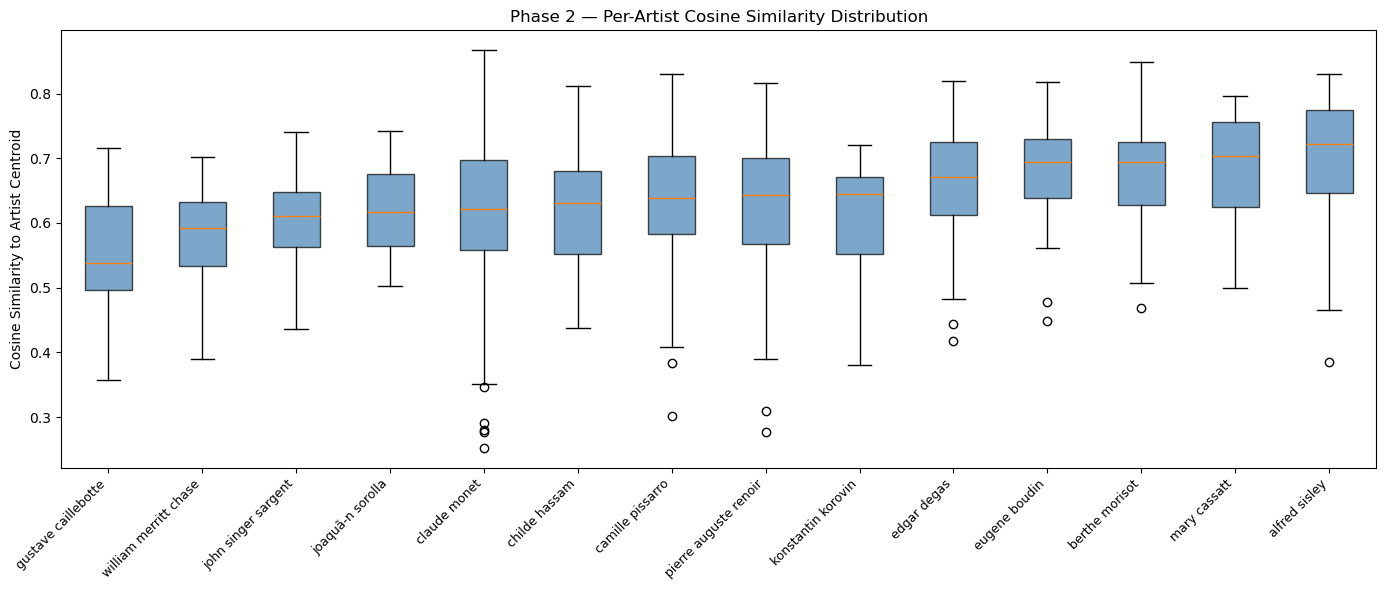

In [ ]:
# Per-artist similarity distribution
fig, ax = plt.subplots(figsize=(14, 6))
artist_order = (
    meta_filtered.groupby('artist')['artist_cosine_sim']
    .median()
    .sort_values()
    .index.tolist()
)
data_to_plot = [meta_filtered[meta_filtered['artist'] == a]['artist_cosine_sim'].values
                for a in artist_order]
bp = ax.boxplot(data_to_plot, labels=artist_order, patch_artist=True, vert=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax.set_xticklabels(artist_order, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Cosine Similarity to Artist Centroid')
ax.set_title('Phase 2 — Per-Artist Cosine Similarity Distribution')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase2_per_artist_boxplot.png', dpi=150)
plt.show()

c:\Users\Yeva\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


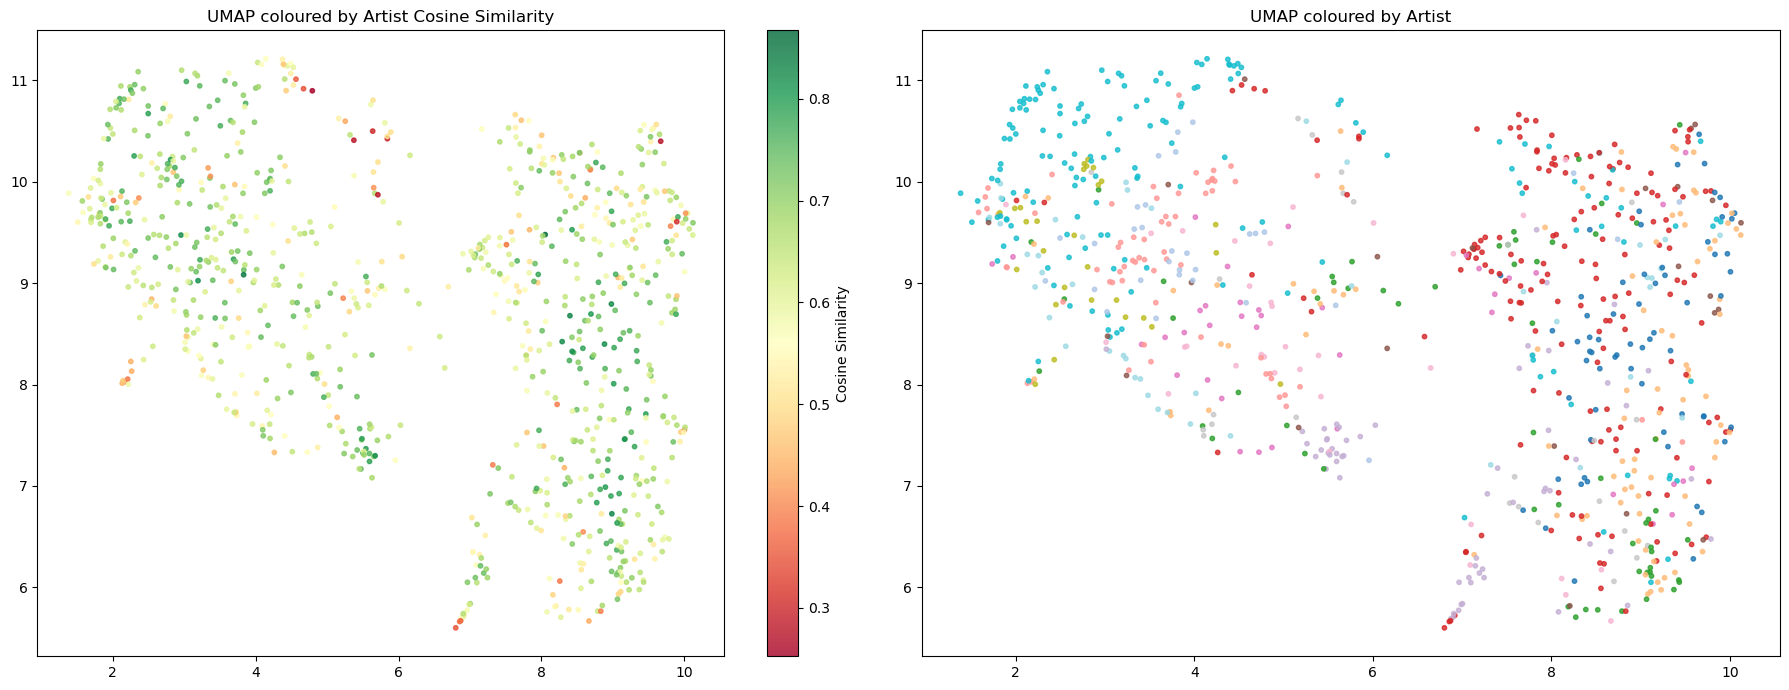

In [ ]:
# UMAP of filtered subset coloured by artist anomaly score 
reducer2 = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
coords2 = reducer2.fit_transform(emb_filtered)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: coloured by anomaly score
sc = axes[0].scatter(coords2[:, 0], coords2[:, 1],
                     c=artist_cosine_scores, cmap='RdYlGn',
                     s=10, alpha=0.8)
plt.colorbar(sc, ax=axes[0], label='Cosine Similarity')
axes[0].set_title('UMAP coloured by Artist Cosine Similarity')

# Right: coloured by artist
artist_codes = meta_filtered['artist'].astype('category').cat.codes
sc2 = axes[1].scatter(coords2[:, 0], coords2[:, 1],
                      c=artist_codes, cmap='tab20',
                      s=10, alpha=0.8)
axes[1].set_title('UMAP coloured by Artist')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase2_umap_artist_similarity.png', dpi=150)
plt.show()

In [ ]:
# Top anomalies per artist
top_per_artist = (
    meta_filtered.sort_values('artist_anomaly_score', ascending=False)
    .groupby('artist')
    .first()
    [['filename', 'artist_cosine_sim', 'artist_anomaly_score']]
    .sort_values('artist_anomaly_score', ascending=False)
    .reset_index()
)
print('Worst outlier per artist:')
top_per_artist.style.background_gradient(subset=['artist_anomaly_score'], cmap='Reds')

Worst outlier per artist:


,artist,filename,artist_cosine_sim,artist_anomaly_score
0,claude monet,Impressionism/claude-monet_dandelions.jpg,0.252469,0.747531
1,pierre auguste renoir,Impressionism/pierre-auguste-renoir_woman-at-the-garden-1873.jpg,0.276408,0.723592
2,camille pissarro,Impressionism/camille-pissarro_pink-peonies-1873.jpg,0.301013,0.698987
3,gustave caillebotte,Impressionism/gustave-caillebotte_peaches-apples-and-grapes-on-a-vine-leaf.jpg,0.357575,0.642425
4,konstantin korovin,Impressionism/konstantin-korovin_on-the-shore-of-the-black-sea.jpg,0.379872,0.620128
5,alfred sisley,Impressionism/alfred-sisley_under-the-bridge-at-hampton-court-1874.jpg,0.385643,0.614357
6,william merritt chase,Impressionism/william-merritt-chase_seascape.jpg,0.390400,0.609600
7,edgar degas,Impressionism/edgar-degas_manet-at-the-races-1870.jpg,0.417063,0.582937
8,john singer sargent,Impressionism/john-singer-sargent_escutcheon-of-charles-v-1912.jpg,0.435409,0.564591
9,childe hassam,Impressionism/childe-hassam_portrait-of-a-lady-in-blue-dress.jpg,0.437294,0.562706


### Phase 1 vs Phase 2 score comparison

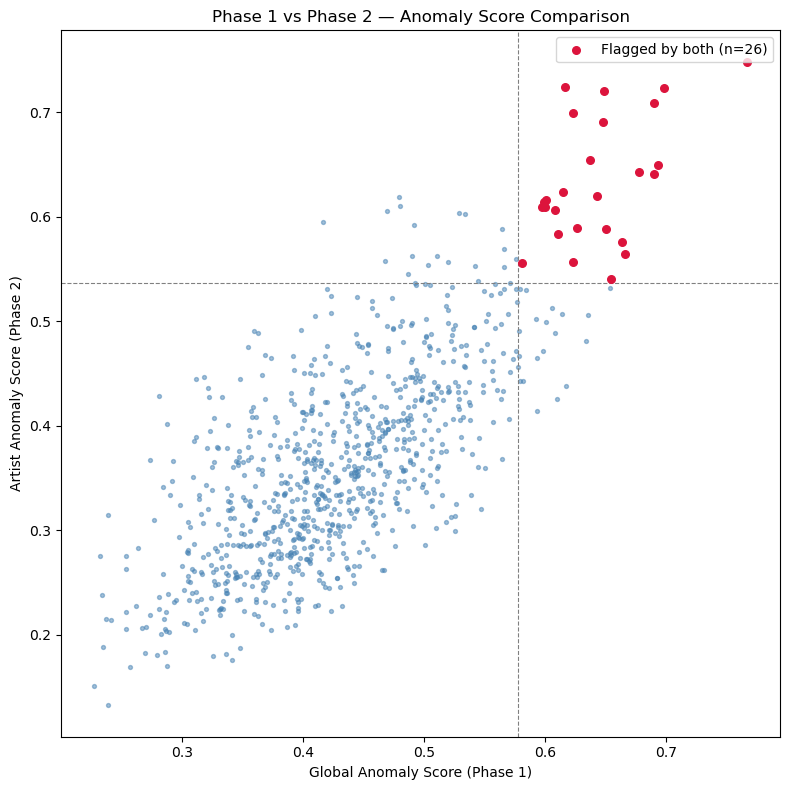

Paintings flagged by both methods: 26
                                                                           filename                 artist  global_anomaly_score  artist_anomaly_score
1                                         Impressionism/claude-monet_dandelions.jpg           claude monet              0.766910              0.747531
2                                        Impressionism/claude-monet_the-tea-set.jpg           claude monet              0.648669              0.720002
10                             Impressionism/camille-pissarro_pink-peonies-1873.jpg       camille pissarro              0.622545              0.698987
182                       Impressionism/pierre-auguste-renoir_sleeping-cat-1862.jpg  pierre auguste renoir              0.650105              0.587963
198                                  Impressionism/claude-monet_boats-on-rapair.jpg           claude monet              0.692924              0.649201
229                           Impressionism/edgar-degas_

In [ ]:
merged = meta_filtered.copy()

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(merged['global_anomaly_score'], merged['artist_anomaly_score'],
           s=8, alpha=0.5, color='steelblue')
ax.set_xlabel('Global Anomaly Score (Phase 1)')
ax.set_ylabel('Artist Anomaly Score (Phase 2)')
ax.set_title('Phase 1 vs Phase 2 — Anomaly Score Comparison')

# Paintings flagged by both
g_thresh = np.percentile(merged['global_anomaly_score'], 95)
a_thresh = np.percentile(merged['artist_anomaly_score'], 95)
both = merged[(merged['global_anomaly_score'] >= g_thresh) &
              (merged['artist_anomaly_score'] >= a_thresh)]
ax.scatter(both['global_anomaly_score'], both['artist_anomaly_score'],
           s=30, color='crimson', label=f'Flagged by both (n={len(both)})', zorder=5)
ax.axvline(g_thresh, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(a_thresh, color='gray', linestyle='--', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase1_vs_phase2_scatter.png', dpi=150)
plt.show()
print(f'Paintings flagged by both methods: {len(both)}')
print(both[['filename', 'artist', 'global_anomaly_score', 'artist_anomaly_score']].to_string())

In [ ]:
# Phase 2 scores
meta_filtered[['filename', 'artist', 'artist_cosine_sim', 'artist_anomaly_score']].to_csv(
    RESULTS_DIR / 'phase2_artist_cosine_scores.csv', index=False
)
print('Saved → results/phase2_artist_cosine_scores.csv')
print()
print('All done. Next: Isolation Forest on the same embeddings for comparison.')

Saved → results/phase2_artist_cosine_scores.csv

All done. Next: Isolation Forest on the same embeddings for comparison.
